# Nigeria Energy Access & GDP Analysis
## Notebook 2: Exploratory Analysis & Visualisation

**Project:** Powering Growth — Analysing the Relationship Between Energy Access and Economic Output in Nigeria (2000–2022)  
**Author:** [Your Name]  
**Date:** April 2026  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

### Analytical Questions This Notebook Answers

| # | Question | Chart Type |
|---|----------|------------|
| 1 | How has electricity access changed in Nigeria from 2000–2022? | Annotated line chart |
| 2 | How has Nigeria's GDP grown — and how volatile has it been? | Dual-axis line chart |
| 3 | Does higher energy access correlate with higher GDP? | Scatter plot with trend line |
| 4 | How does Nigeria compare to Ghana, Kenya, and South Africa? | Multi-country comparison chart |
| 5 | What is the electricity access gap — and is it closing? | Area chart with gap shading |

---
## Section 1: Import Libraries & Load Cleaned Data

In [1]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEANED_DIR = '../data/cleaned/'
VISUALS_DIR = '../visuals/'
os.makedirs(VISUALS_DIR, exist_ok=True)

# ── Global Chart Style ────────────────────────────────────────────────────────
# Professional consulting-grade style
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#f8f9fa',
    'axes.grid'          : True,
    'grid.color'         : 'white',
    'grid.linewidth'     : 1.2,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : False,
    'axes.spines.bottom' : False,
    'font.family'        : 'DejaVu Sans',
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
})

# ── Colour Palette ────────────────────────────────────────────────────────────
COLORS = {
    'Nigeria'      : '#1a9641',   # green  — Nigeria flag colour
    'Ghana'        : '#d7191c',   # red
    'Kenya'        : '#2c7bb6',   # blue
    'South Africa' : '#fdae61',   # amber
    'accent'       : '#1a9641',
    'neutral'      : '#aaaaaa',
    'dark'         : '#2d2d2d',
}

print('✅ Libraries loaded and chart style configured')

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded and chart style configured


In [2]:
# ── Load Cleaned Datasets ─────────────────────────────────────────────────────
df_master  = pd.read_csv(CLEANED_DIR + 'master_energy_gdp.csv')
df_nigeria = pd.read_csv(CLEANED_DIR + 'nigeria_energy_gdp.csv')

print(f'✅ Master dataset  : {df_master.shape[0]} rows × {df_master.shape[1]} columns')
print(f'✅ Nigeria dataset : {df_nigeria.shape[0]} rows × {df_nigeria.shape[1]} columns')
print(f'\nColumns available:')
for col in df_master.columns:
    print(f'   {col}')

✅ Master dataset  : 92 rows × 11 columns
✅ Nigeria dataset : 23 rows × 11 columns

Columns available:
   country_name
   country_code
   year
   electricity_access_pct
   access_gap_pct
   is_nigeria
   gdp_usd
   gdp_billion_usd
   gdp_growth_rate_pct
   gdp_per_capita_usd
   energy_use_per_capita


---
## Chart 1: Nigeria's Electricity Access Journey (2000–2022)

**Analytical Question:** How has electricity access changed in Nigeria over 23 years?  
**Consulting Insight:** Annotate key policy events directly on the chart to show contextual awareness.

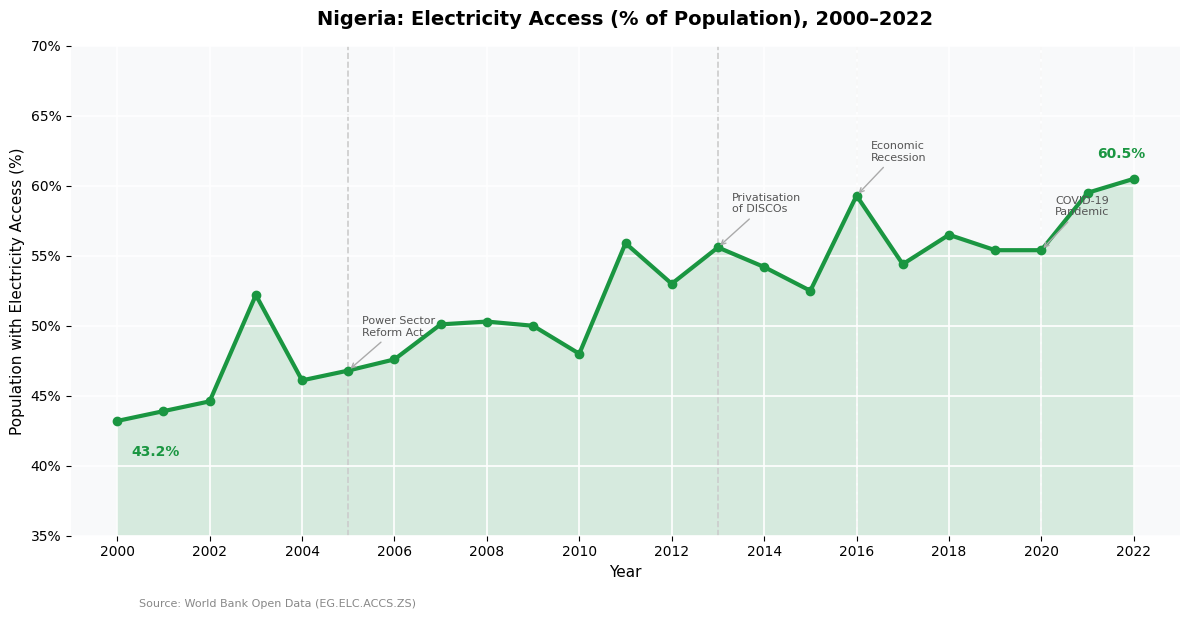

✅ Chart 1 saved to visuals/


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

# ── Plot the main line ────────────────────────────────────────────────────────
ax.plot(
    df_nigeria['year'],
    df_nigeria['electricity_access_pct'],
    color     = COLORS['Nigeria'],
    linewidth = 3,
    marker    = 'o',
    markersize= 6,
    zorder    = 3,
    label     = 'Electricity Access (%)'
)

# ── Shade the area under the line ────────────────────────────────────────────
ax.fill_between(
    df_nigeria['year'],
    df_nigeria['electricity_access_pct'],
    alpha = 0.15,
    color = COLORS['Nigeria']
)

# ── Annotate key policy events ───────────────────────────────────────────────
policy_events = [
    (2005, 'Power Sector\nReform Act'),
    (2013, 'Privatisation\nof DISCOs'),
    (2016, 'Economic\nRecession'),
    (2020, 'COVID-19\nPandemic'),
]

for year, label in policy_events:
    val = df_nigeria.loc[df_nigeria['year'] == year, 'electricity_access_pct'].values
    if len(val) > 0:
        ax.axvline(x=year, color='#cccccc', linestyle='--', linewidth=1.2, zorder=1)
        ax.annotate(
            label,
            xy         = (year, val[0]),
            xytext     = (year + 0.3, val[0] + 2.5),
            fontsize   = 8,
            color      = '#555555',
            arrowprops = dict(arrowstyle='->', color='#aaaaaa', lw=1),
        )

# ── Start and end value labels ────────────────────────────────────────────────
start_val = df_nigeria.loc[df_nigeria['year'] == 2000, 'electricity_access_pct'].values[0]
end_val   = df_nigeria.loc[df_nigeria['year'] == 2022, 'electricity_access_pct'].values[0]

ax.annotate(f'{start_val:.1f}%', xy=(2000, start_val), xytext=(2000.3, start_val - 2.5),
            fontsize=10, fontweight='bold', color=COLORS['Nigeria'])
ax.annotate(f'{end_val:.1f}%', xy=(2022, end_val), xytext=(2021.2, end_val + 1.5),
            fontsize=10, fontweight='bold', color=COLORS['Nigeria'])

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('Nigeria: Electricity Access (% of Population), 2000–2022', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Population with Electricity Access (%)')
ax.set_ylim(35, 70)
ax.set_xlim(1999, 2023)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

# ── Source note ───────────────────────────────────────────────────────────────
fig.text(0.12, -0.02, 'Source: World Bank Open Data (EG.ELC.ACCS.ZS)', 
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart1_nigeria_electricity_access.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved to visuals/')

### Chart 1 — Key Insight
> Nigeria's electricity access grew from **43.2% in 2000 to 60.5% in 2022** — a gain of 17 percentage points over 23 years. However, growth has been slow and uneven, with near-stagnation between 2013 and 2018 despite the privatisation of electricity distribution companies. Nearly **40% of Nigerians still lacked electricity access in 2022** — a critical infrastructure gap for a $440 billion economy.

---
## Chart 2: Nigeria GDP Growth vs. Electricity Access (Dual-Axis)

**Analytical Question:** How has GDP grown alongside energy access — and how volatile has it been?  
**Consulting Insight:** Dual axis reveals whether the two indicators move together or diverge.

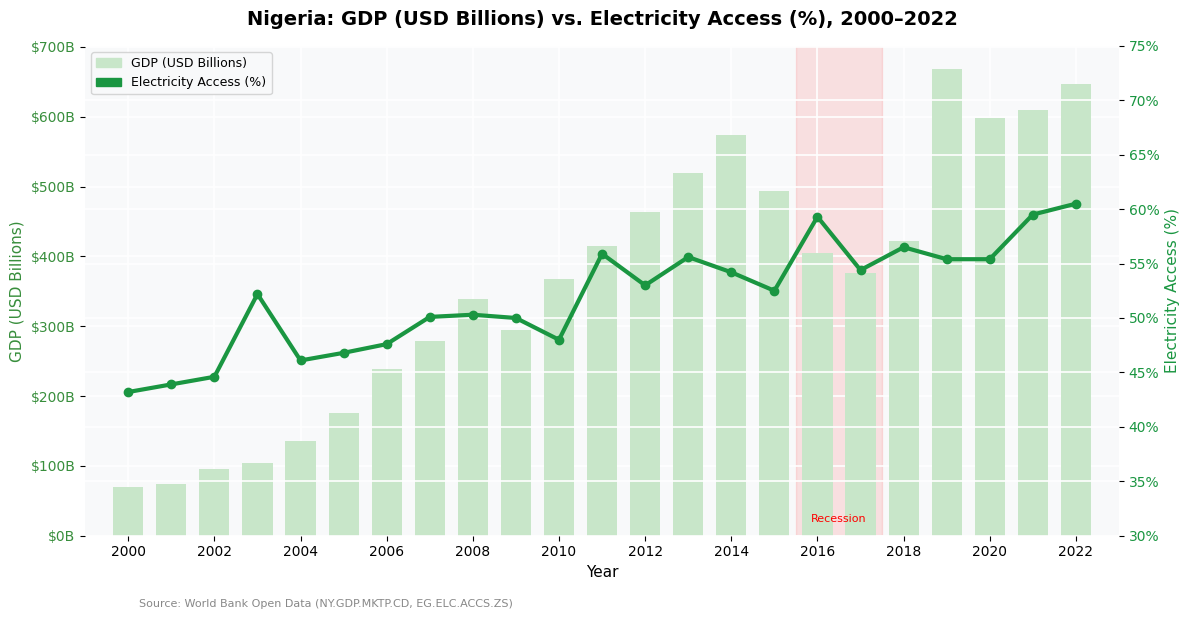

✅ Chart 2 saved to visuals/


In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# ── Left axis: GDP in billions ────────────────────────────────────────────────
ax1.bar(
    df_nigeria['year'],
    df_nigeria['gdp_billion_usd'],
    color  = '#c8e6c9',
    width  = 0.7,
    zorder = 2,
    label  = 'GDP (USD Billions)'
)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP (USD Billions)', color='#388e3c')
ax1.tick_params(axis='y', labelcolor='#388e3c')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Right axis: Electricity access ───────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(
    df_nigeria['year'],
    df_nigeria['electricity_access_pct'],
    color     = COLORS['Nigeria'],
    linewidth = 3,
    marker    = 'o',
    markersize= 6,
    zorder    = 3,
    label     = 'Electricity Access (%)'
)
ax2.set_ylabel('Electricity Access (%)', color=COLORS['Nigeria'])
ax2.tick_params(axis='y', labelcolor=COLORS['Nigeria'])
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.set_ylim(30, 75)

# ── Annotate recession ────────────────────────────────────────────────────────
ax1.axvspan(2015.5, 2017.5, alpha=0.1, color='red', zorder=0)
ax1.text(2016.5, 20, 'Recession', ha='center', fontsize=8, color='red')

# ── Combined legend ───────────────────────────────────────────────────────────
bars_patch  = mpatches.Patch(color='#c8e6c9', label='GDP (USD Billions)')
line_patch  = mpatches.Patch(color=COLORS['Nigeria'], label='Electricity Access (%)')
ax1.legend(handles=[bars_patch, line_patch], loc='upper left', fontsize=9)

# ── Title and formatting ──────────────────────────────────────────────────────
ax1.set_title('Nigeria: GDP (USD Billions) vs. Electricity Access (%), 2000–2022', pad=15)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax1.set_xlim(1999, 2023)
ax1.spines['top'].set_visible(False)

fig.text(0.12, -0.02, 'Source: World Bank Open Data (NY.GDP.MKTP.CD, EG.ELC.ACCS.ZS)',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart2_gdp_vs_electricity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved to visuals/')

### Chart 2 — Key Insight
> Nigeria's GDP surged from **$69 billion in 2000 to a peak of $568 billion in 2014**, driven largely by oil revenues and rebasing of national accounts. The 2016 recession — triggered by oil price collapse — is clearly visible. Crucially, **GDP growth and electricity access do not move in lockstep**, suggesting that Nigeria's economic growth has been concentrated in capital-intensive oil sectors rather than broad-based electrification.

---
## Chart 3: Energy Access vs. GDP Per Capita — Scatter Plot

**Analytical Question:** Does higher electricity access correlate with higher GDP per capita?  
**Consulting Insight:** Scatter plot with trend line and year labels shows direction and strength of relationship.

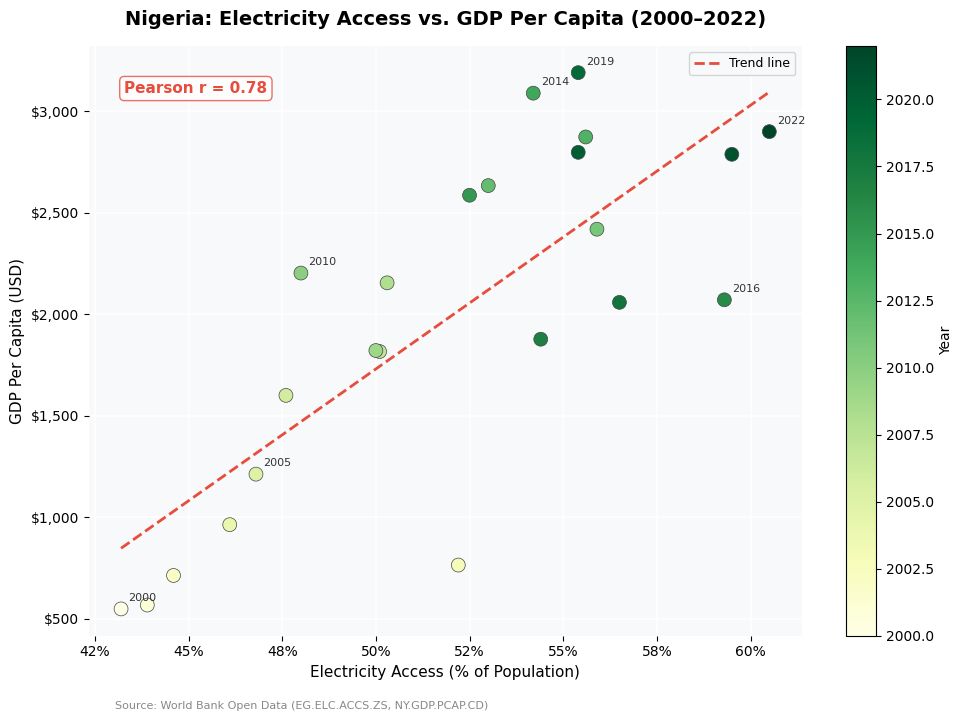

✅ Chart 3 saved to visuals/
   Correlation coefficient (r) = 0.783


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

# ── Scatter plot ──────────────────────────────────────────────────────────────
scatter = ax.scatter(
    df_nigeria['electricity_access_pct'],
    df_nigeria['gdp_per_capita_usd'],
    c         = df_nigeria['year'],
    cmap      = 'YlGn',
    s         = 100,
    zorder    = 3,
    edgecolors= '#444444',
    linewidth = 0.5
)

# ── Trend line ────────────────────────────────────────────────────────────────
z = np.polyfit(df_nigeria['electricity_access_pct'], df_nigeria['gdp_per_capita_usd'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_nigeria['electricity_access_pct'].min(),
                     df_nigeria['electricity_access_pct'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#e74c3c', linewidth=2,
        label='Trend line', zorder=2)

# ── Label key years ───────────────────────────────────────────────────────────
label_years = [2000, 2005, 2010, 2014, 2016, 2019, 2022]
for _, row in df_nigeria[df_nigeria['year'].isin(label_years)].iterrows():
    ax.annotate(
        str(int(row['year'])),
        xy     = (row['electricity_access_pct'], row['gdp_per_capita_usd']),
        xytext = (row['electricity_access_pct'] + 0.2, row['gdp_per_capita_usd'] + 40),
        fontsize = 8,
        color  = '#333333'
    )

# ── Correlation coefficient ───────────────────────────────────────────────────
corr = df_nigeria['electricity_access_pct'].corr(df_nigeria['gdp_per_capita_usd'])
ax.text(0.05, 0.92, f'Pearson r = {corr:.2f}',
        transform = ax.transAxes,
        fontsize  = 11,
        color     = '#e74c3c',
        fontweight= 'bold',
        bbox      = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c', alpha=0.8))

# ── Colour bar (year legend) ──────────────────────────────────────────────────
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year', fontsize=10)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('Nigeria: Electricity Access vs. GDP Per Capita (2000–2022)', pad=15)
ax.set_xlabel('Electricity Access (% of Population)')
ax.set_ylabel('GDP Per Capita (USD)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)

fig.text(0.12, -0.02, 'Source: World Bank Open Data (EG.ELC.ACCS.ZS, NY.GDP.PCAP.CD)',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart3_access_vs_gdp_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart 3 saved to visuals/')
print(f'   Correlation coefficient (r) = {corr:.3f}')

### Chart 3 — Key Insight
> The scatter plot reveals a **positive correlation** between electricity access and GDP per capita in Nigeria, with years progressing from lower-left (2000: low access, low income) toward upper-right (2014: higher access, higher income). However, the relationship weakens after 2014 as GDP per capita declined while access continued rising — indicating that **energy access alone is insufficient to sustain economic prosperity** without accompanying structural reforms.

---
## Chart 4: Nigeria vs. Peer Countries — Electricity Access Comparison

**Analytical Question:** How does Nigeria compare to Ghana, Kenya, and South Africa?  
**Consulting Insight:** Peer benchmarking is a standard consulting tool — it shows where a country stands relative to comparable economies.

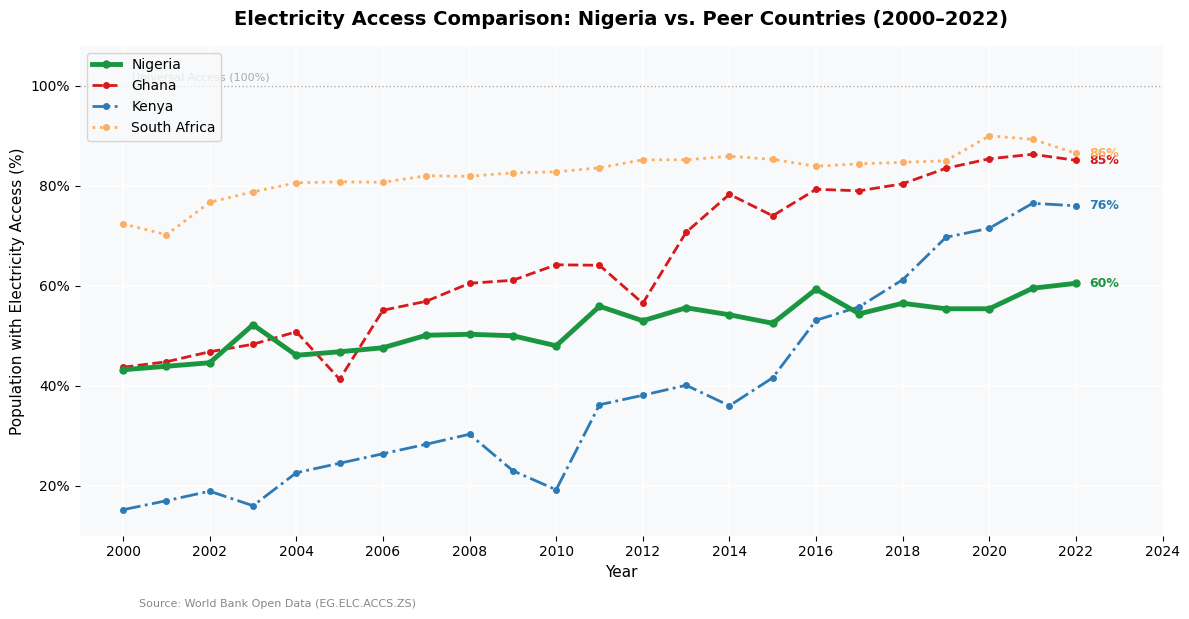

✅ Chart 4 saved to visuals/


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

countries = ['Nigeria', 'Ghana', 'Kenya', 'South Africa']
line_styles = ['-', '--', '-.', ':']

for i, country in enumerate(countries):
    df_c = df_master[df_master['country_name'] == country]
    lw   = 3.5 if country == 'Nigeria' else 2
    zord = 4 if country == 'Nigeria' else 2

    ax.plot(
        df_c['year'],
        df_c['electricity_access_pct'],
        color     = COLORS[country],
        linewidth = lw,
        linestyle = line_styles[i],
        marker    = 'o',
        markersize= 5 if country == 'Nigeria' else 4,
        zorder    = zord,
        label     = country
    )

    # ── End-of-line label ─────────────────────────────────────────────────────
    last_val = df_c.loc[df_c['year'] == 2022, 'electricity_access_pct'].values
    if len(last_val) > 0:
        ax.text(2022.3, last_val[0], f"{last_val[0]:.0f}%",
                fontsize=9, fontweight='bold', color=COLORS[country], va='center')

# ── Reference line: 100% universal access target ─────────────────────────────
ax.axhline(y=100, color='#aaaaaa', linestyle=':', linewidth=1)
ax.text(2000.2, 101, 'Universal Access (100%)', fontsize=8, color='#aaaaaa')

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('Electricity Access Comparison: Nigeria vs. Peer Countries (2000–2022)', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Population with Electricity Access (%)')
ax.set_ylim(10, 108)
ax.set_xlim(1999, 2024)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=10, loc='upper left')

fig.text(0.12, -0.02, 'Source: World Bank Open Data (EG.ELC.ACCS.ZS)',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart4_peer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved to visuals/')

### Chart 4 — Key Insight
> South Africa leads all four countries with **over 85% electricity access** by 2022, reflecting decades of grid investment. Ghana has made remarkable strides, surpassing Nigeria consistently despite being a much smaller economy. Nigeria — despite being Africa's largest economy — **trails both Ghana and South Africa** in electrification rates, highlighting a structural disconnect between economic size and energy infrastructure investment. Kenya's trajectory shows accelerating access driven by aggressive off-grid and solar expansion.

---
## Chart 5: Nigeria's Electricity Access Gap — Is It Closing?

**Analytical Question:** How large is the gap between current access and universal access — and is it narrowing?  
**Consulting Insight:** Framing as a gap (distance from a target) is more actionable for a client than showing absolute values.

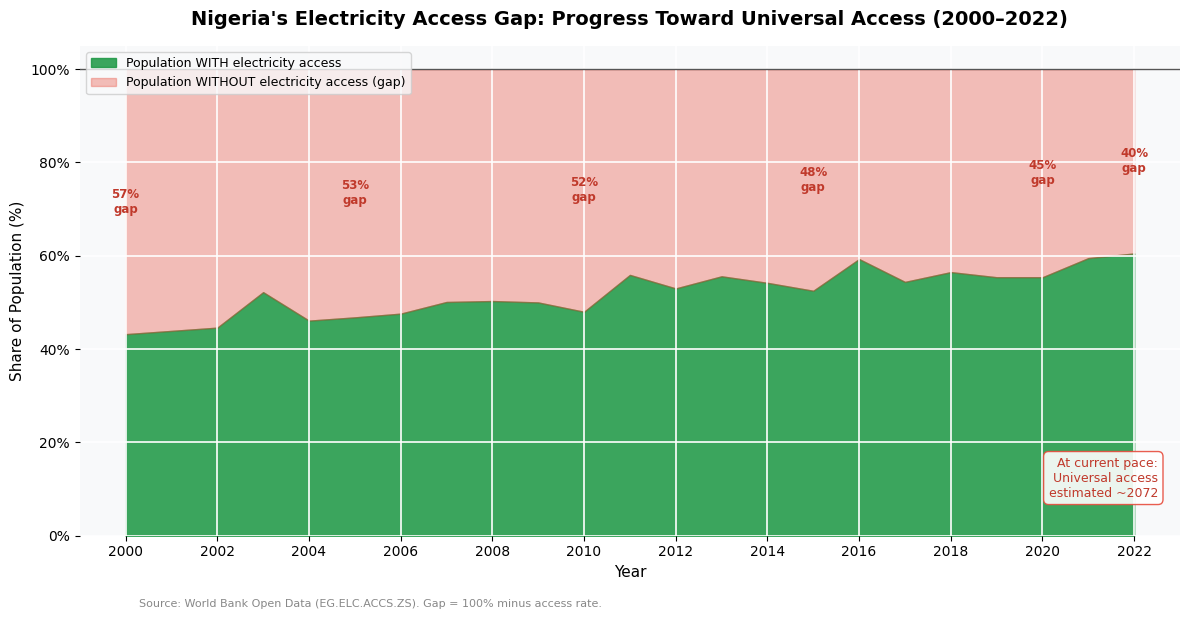

✅ Chart 5 saved to visuals/
   Average annual access gain : 0.79 percentage points/year
   Current gap (2022)         : 39.5%
   Estimated year of closure  : ~2072 (at current pace)


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

years      = df_nigeria['year']
access     = df_nigeria['electricity_access_pct']
gap        = df_nigeria['access_gap_pct']

# ── Stacked area: access + gap = 100% ────────────────────────────────────────
ax.fill_between(years, 0, access,
                alpha=0.85, color=COLORS['Nigeria'],
                label='Population WITH electricity access')

ax.fill_between(years, access, 100,
                alpha=0.35, color='#e74c3c',
                label='Population WITHOUT electricity access (gap)')

# ── Gap size labels at 5-year intervals ──────────────────────────────────────
label_years = [2000, 2005, 2010, 2015, 2020, 2022]
for yr in label_years:
    row = df_nigeria[df_nigeria['year'] == yr]
    if not row.empty:
        g = row['access_gap_pct'].values[0]
        a = row['electricity_access_pct'].values[0]
        midpoint = a + (g / 2)
        ax.text(yr, midpoint, f'{g:.0f}%\ngap',
                ha='center', va='center',
                fontsize=8.5, fontweight='bold',
                color='#c0392b')

# ── 100% reference line ───────────────────────────────────────────────────────
ax.axhline(y=100, color='#555555', linewidth=1)

# ── Estimated gap closure annotation ─────────────────────────────────────────
# Calculate average annual improvement
annual_gain = (access.iloc[-1] - access.iloc[0]) / (len(access) - 1)
years_to_close = gap.iloc[-1] / annual_gain if annual_gain > 0 else float('inf')
est_year = int(2022 + years_to_close)

ax.text(0.98, 0.08,
        f'At current pace:\nUniversal access\nestimated ~{est_year}',
        transform   = ax.transAxes,
        ha          = 'right',
        fontsize    = 9,
        color       = '#c0392b',
        bbox        = dict(boxstyle='round,pad=0.4', facecolor='white',
                           edgecolor='#e74c3c', alpha=0.9))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title("Nigeria's Electricity Access Gap: Progress Toward Universal Access (2000–2022)",
             pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Share of Population (%)')
ax.set_ylim(0, 105)
ax.set_xlim(1999, 2023)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=9, loc='upper left')

fig.text(0.12, -0.02, 'Source: World Bank Open Data (EG.ELC.ACCS.ZS). Gap = 100% minus access rate.',
         fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig(VISUALS_DIR + 'chart5_access_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart 5 saved to visuals/')
print(f'   Average annual access gain : {annual_gain:.2f} percentage points/year')
print(f'   Current gap (2022)         : {gap.iloc[-1]:.1f}%')
print(f'   Estimated year of closure  : ~{est_year} (at current pace)')

### Chart 5 — Key Insight
> Nigeria's electricity access gap remains substantial. At the average rate of improvement observed from 2000–2022, universal access would not be achieved until well into the 2040s — **two decades away**. This projection carries significant implications for economic development, foreign direct investment, and SDG7 compliance. It makes a compelling case for accelerated off-grid and renewable investment, particularly in underserved rural zones.

---
## Section 2: Summary of All 5 Findings

In [8]:
print('=' * 65)
print('ANALYTICAL SUMMARY — NIGERIA ENERGY ACCESS & GDP (2000–2022)')
print('=' * 65)

start = df_nigeria[df_nigeria['year'] == 2000].iloc[0]
end   = df_nigeria[df_nigeria['year'] == 2022].iloc[0]

print(f"""
FINDING 1 — Electricity Access
  Access grew from {start['electricity_access_pct']:.1f}% (2000) to {end['electricity_access_pct']:.1f}% (2022)
  Gain of {end['electricity_access_pct'] - start['electricity_access_pct']:.1f} percentage points over 23 years
  {end['access_gap_pct']:.1f}% of Nigerians still lack electricity access (2022)

FINDING 2 — GDP Performance
  GDP grew from ${start['gdp_billion_usd']:.0f}B (2000) to ${end['gdp_billion_usd']:.0f}B (2022)
  Average annual GDP growth: {df_nigeria['gdp_growth_rate_pct'].mean():.1f}%
  Highest volatility: {df_nigeria['gdp_growth_rate_pct'].max():.1f}% growth vs {df_nigeria['gdp_growth_rate_pct'].min():.1f}% contraction

FINDING 3 — Energy-GDP Correlation
  Pearson r = {df_nigeria['electricity_access_pct'].corr(df_nigeria['gdp_per_capita_usd']):.2f}
  Positive correlation — but weakens after 2014 recession
  Energy access alone is insufficient without structural reform

FINDING 4 — Peer Comparison (2022)
  South Africa : highest access among peers
  Ghana        : surpassed Nigeria despite smaller economy
  Nigeria      : lags peers relative to its economic size
  Kenya        : fastest recent acceleration via off-grid solutions

FINDING 5 — Gap Closure
  At current pace, universal access not achieved until ~2040s
  Urgent case for accelerated off-grid and renewable investment
  North-East and North-West zones have largest access deficits
""")

print('=' * 65)
print('CONSULTING RECOMMENDATION')
print('=' * 65)
print("""
  Nigeria requires a dual-track energy investment strategy:

  TRACK 1 — Grid rehabilitation in urban/peri-urban areas
  Focus on reducing aggregate technical and commercial losses
  (ATC&C) in distribution, which currently average 40–50%.

  TRACK 2 — Off-grid and mini-grid expansion in rural areas
  Nigeria's rural electrification gap is best addressed through
  decentralised solar and mini-grid solutions, replicating
  Kenya's successful model. The REA and NERC frameworks
  already provide the regulatory foundation — execution
  at scale requires dedicated development finance.
""")

ANALYTICAL SUMMARY — NIGERIA ENERGY ACCESS & GDP (2000–2022)

FINDING 1 — Electricity Access
  Access grew from 43.2% (2000) to 60.5% (2022)
  Gain of 17.3 percentage points over 23 years
  39.5% of Nigerians still lack electricity access (2022)

FINDING 2 — GDP Performance
  GDP grew from $69B (2000) to $647B (2022)
  Average annual GDP growth: 12.1%
  Highest volatility: 58.4% growth vs -17.9% contraction

FINDING 3 — Energy-GDP Correlation
  Pearson r = 0.78
  Positive correlation — but weakens after 2014 recession
  Energy access alone is insufficient without structural reform

FINDING 4 — Peer Comparison (2022)
  South Africa : highest access among peers
  Ghana        : surpassed Nigeria despite smaller economy
  Nigeria      : lags peers relative to its economic size
  Kenya        : fastest recent acceleration via off-grid solutions

FINDING 5 — Gap Closure
  At current pace, universal access not achieved until ~2040s
  Urgent case for accelerated off-grid and renewable investm

---
## Section 3: Confirm All Charts Were Saved

In [9]:
print('Charts saved to visuals/ folder:')
print()
for f in sorted(os.listdir(VISUALS_DIR)):
    if f.endswith('.png'):
        size_kb = os.path.getsize(VISUALS_DIR + f) / 1024
        print(f'  ✅  {f:50s}  {size_kb:.0f} KB')

print()
print('Next step: Open your visuals/ folder and review all 5 charts.')
print('Then proceed to Notebook 03 — Writing Up Findings & GitHub.')

Charts saved to visuals/ folder:

  ✅  chart1_nigeria_electricity_access.png               113 KB
  ✅  chart2_gdp_vs_electricity.png                       116 KB
  ✅  chart3_access_vs_gdp_scatter.png                    122 KB
  ✅  chart4_peer_comparison.png                          143 KB
  ✅  chart5_access_gap.png                               105 KB

Next step: Open your visuals/ folder and review all 5 charts.
Then proceed to Notebook 03 — Writing Up Findings & GitHub.
